<a href="https://colab.research.google.com/github/jfjofilipe/Aulas_2024/blob/main/HANDS12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

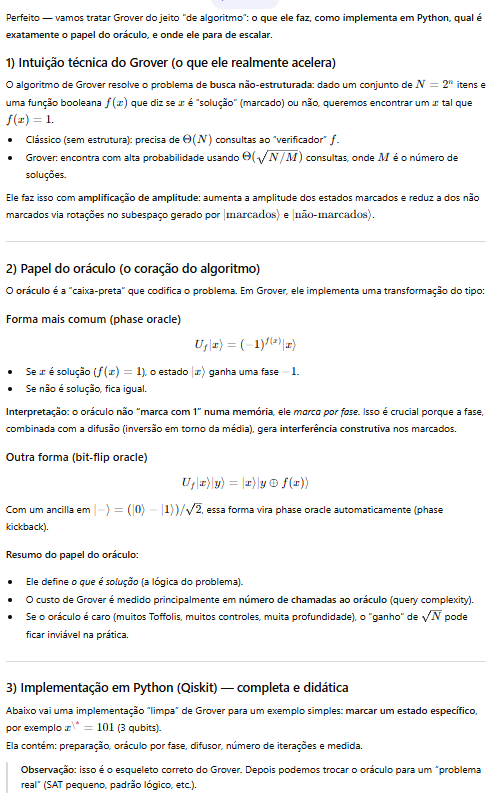

In [ ]:
!pip install qiskit qiskit_aer

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def apply_phase_oracle_mark_state(qc: QuantumCircuit, marked: str):
    """
    Phase oracle that flips the phase of |marked>.
    marked: bitstring like '101' (MSB->LSB in human reading).
    Qiskit qubit order is little-endian (qubit 0 is LSB in measurement string).
    We'll map carefully by applying X gates to match.
    """
    n = len(marked)

    # Convert marked string (MSB->LSB) to qubit-wise targets (q[n-1]..q[0])
    # Measurement in Qiskit returns bits in order q[n-1]...q[0] in the classical string.
    # We'll use that convention and address qubits directly.
    for i, bit in enumerate(reversed(marked)):  # reversed => LSB first for qubit indexing
        if bit == '0':
            qc.x(i)

    # Multi-controlled Z: implement via H on target + MCX + H (turns X into Z)
    # Choose last qubit as target:
    target = n - 1
    controls = list(range(n - 1))

    qc.h(target)
    if len(controls) == 0:
        qc.z(target)
    else:
        qc.mcx(controls, target)  # multi-controlled X
    qc.h(target)

    # Undo X gates
    for i, bit in enumerate(reversed(marked)):
        if bit == '0':
            qc.x(i)

def apply_diffuser(qc: QuantumCircuit, n: int):
    """
    Standard Grover diffuser (inversion about the mean).
    """
    qc.h(range(n))
    qc.x(range(n))

    target = n - 1
    controls = list(range(n - 1))

    qc.h(target)
    if len(controls) == 0:
        qc.z(target)
    else:
        qc.mcx(controls, target)
    qc.h(target)

    qc.x(range(n))
    qc.h(range(n))

def grover_circuit(n: int, marked: str, iterations: int):
    qc = QuantumCircuit(n, n)

    # 1) Start in uniform superposition
    qc.h(range(n))

    # 2) Grover iterations
    for _ in range(iterations):
        apply_phase_oracle_mark_state(qc, marked)
        apply_diffuser(qc, n)

    # 3) Measure
    qc.measure(range(n), range(n))
    return qc

# Example: n=3, marked state = '101'
n = 3
marked = "101"
N = 2**n
M = 1

# Optimal iterations ~ floor(pi/4 * sqrt(N/M))
k_opt = int(np.floor((np.pi/4) * np.sqrt(N/M)))

qc = grover_circuit(n, marked, k_opt)

sim = AerSimulator()
result = sim.run(qc, shots=2000).result()
counts = result.get_counts()

print("k_opt =", k_opt)
print(counts)


k_opt = 2
{'001': 16, '110': 12, '100': 17, '010': 15, '000': 19, '111': 5, '011': 12, '101': 1904}


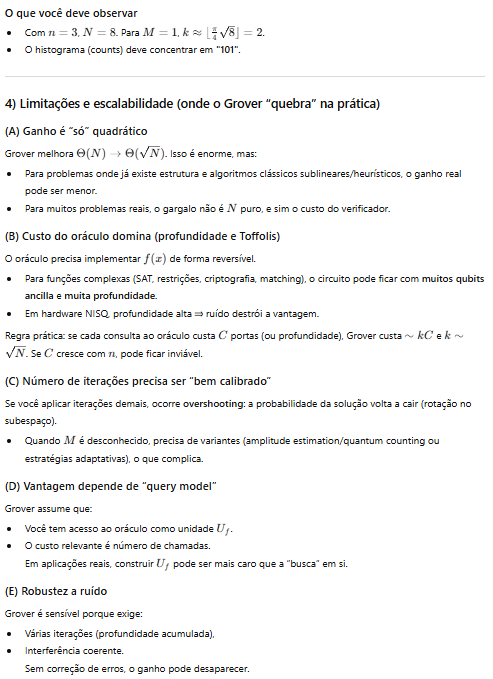


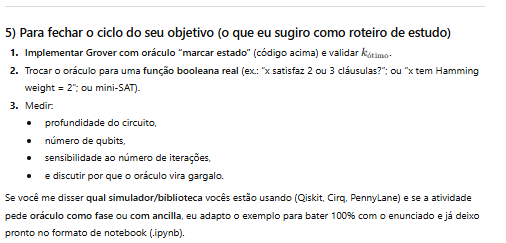

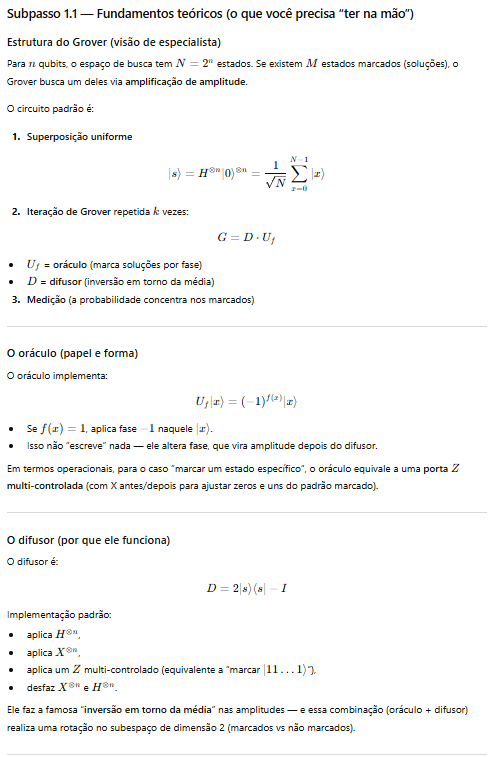



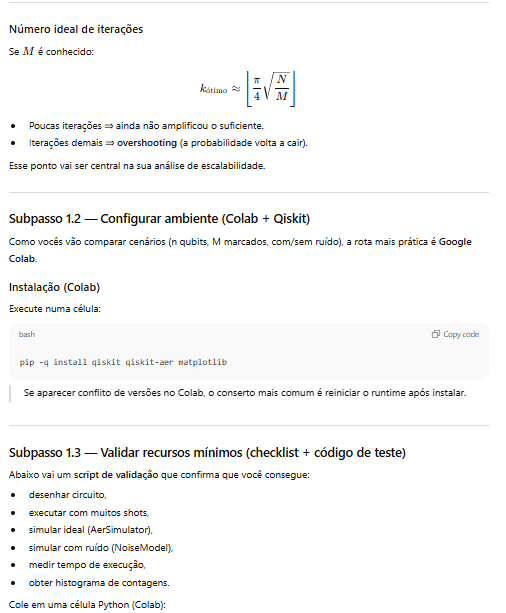



     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
Ideal counts: {'11': 989, '00': 1011}
Ideal execution time: 8.85 ms


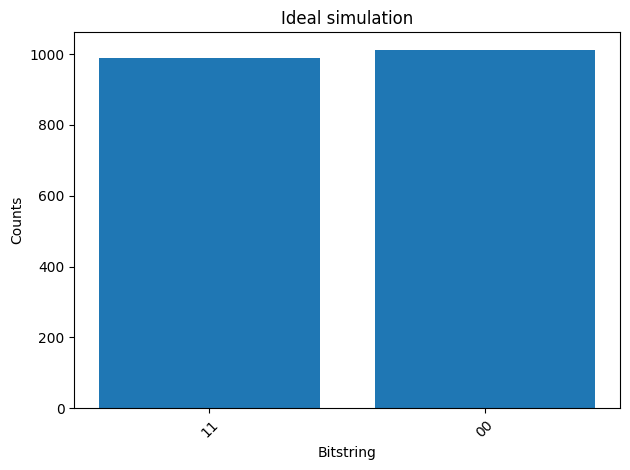

Noisy counts: {'01': 3, '10': 6, '00': 1046, '11': 945}
Noisy execution time: 5.10 ms


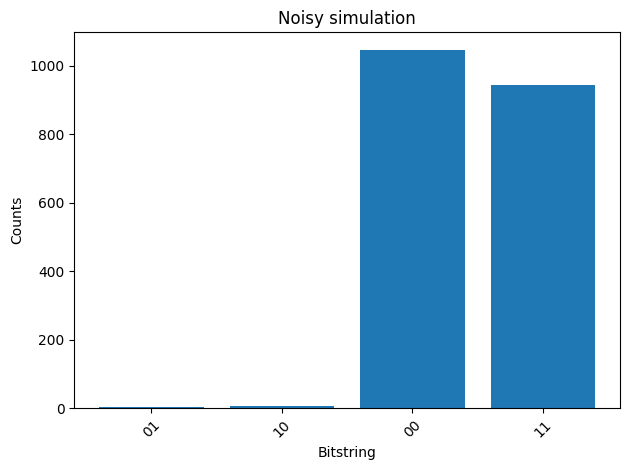

In [ ]:
import time
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

def plot_counts(counts, title="Counts"):
    # plot simples sem seaborn
    labels = list(counts.keys())
    values = [counts[k] for k in labels]
    plt.figure()
    plt.bar(labels, values)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.xlabel("Bitstring")
    plt.ylabel("Counts")
    plt.tight_layout()
    plt.show()

# 1) circuito simples para validar desenho + execução
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0,1], [0,1])

print(qc.draw("text"))  # circuito em texto

# 2) simulador ideal
ideal_sim = AerSimulator()

t0 = time.perf_counter()
ideal_res = ideal_sim.run(qc, shots=2000).result()
t1 = time.perf_counter()

ideal_counts = ideal_res.get_counts()
print("Ideal counts:", ideal_counts)
print(f"Ideal execution time: {(t1-t0)*1000:.2f} ms")

plot_counts(ideal_counts, "Ideal simulation")

# 3) simulador com ruído (exemplo: depolarizing no H e CX)
noise_model = NoiseModel()
p1 = 0.002  # erro 1-qubit
p2 = 0.01   # erro 2-qubit

noise_model.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ['h'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ['cx'])

noisy_sim = AerSimulator(noise_model=noise_model)

t0 = time.perf_counter()
noisy_res = noisy_sim.run(qc, shots=2000).result()
t1 = time.perf_counter()

noisy_counts = noisy_res.get_counts()
print("Noisy counts:", noisy_counts)
print(f"Noisy execution time: {(t1-t0)*1000:.2f} ms")

plot_counts(noisy_counts, "Noisy simulation")


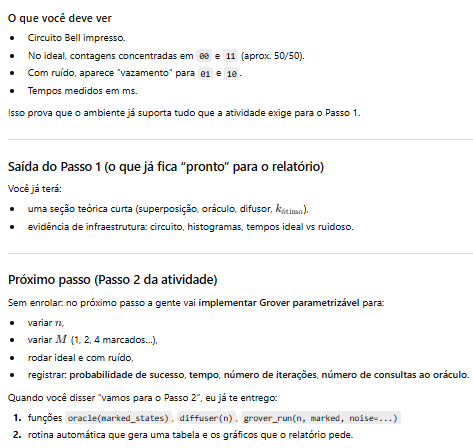

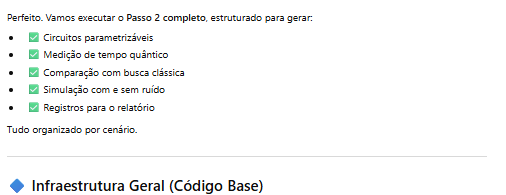



In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# -------------------------
# ORÁCULO (múltiplos alvos)
# -------------------------
def apply_oracle(qc, marked_states):
    n = qc.num_qubits

    for marked in marked_states:
        bitstring = format(marked, f'0{n}b')

        # Ajustar X para bits 0
        for i, bit in enumerate(reversed(bitstring)):
            if bit == '0':
                qc.x(i)

        target = n - 1
        controls = list(range(n - 1))

        qc.h(target)
        if len(controls) > 0:
            qc.mcx(controls, target)
        else:
            qc.z(target)
        qc.h(target)

        # Desfazer X
        for i, bit in enumerate(reversed(bitstring)):
            if bit == '0':
                qc.x(i)

# -------------------------
# DIFUSOR
# -------------------------
def apply_diffuser(qc):
    n = qc.num_qubits

    qc.h(range(n))
    qc.x(range(n))

    target = n - 1
    controls = list(range(n - 1))

    qc.h(target)
    if len(controls) > 0:
        qc.mcx(controls, target)
    else:
        qc.z(target)
    qc.h(target)

    qc.x(range(n))
    qc.h(range(n))

# -------------------------
# GROVER
# -------------------------
def grover_run(n, marked_states, shots=2000, noise=False):

    qc = QuantumCircuit(n, n)

    # Superposição
    qc.h(range(n))

    N = 2**n
    M = len(marked_states)

    k = int(np.floor((np.pi/4)*np.sqrt(N/M)))

    for _ in range(k):
        apply_oracle(qc, marked_states)
        apply_diffuser(qc)

    qc.measure(range(n), range(n))

    # Simulação
    if noise:
        noise_model = NoiseModel()
        noise_model.add_all_qubit_quantum_error(
            depolarizing_error(0.002, 1), ['h'])
        noise_model.add_all_qubit_quantum_error(
            depolarizing_error(0.01, 2), ['mcx'])
        simulator = AerSimulator(noise_model=noise_model)
    else:
        simulator = AerSimulator()

    t0 = time.perf_counter()
    result = simulator.run(qc, shots=shots).result()
    t1 = time.perf_counter()

    counts = result.get_counts()

    return qc, counts, (t1 - t0), k


In [ ]:
#CENÁRIO 1
#2 qubits – 1 alvo

qc, counts, tempo, k = grover_run(2, [3])  # alvo |11>

print("Iterações:", k)
print("Tempo quântico:", tempo)
print(counts)
print(qc.draw("text"))


Iterações: 1
Tempo quântico: 0.007653912999558088
{'11': 2000}
     ┌───┐          ┌───┐┌───┐               ┌───┐┌───┐     ┌─┐   
q_0: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├─────┤M├───
     ├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤├───┤┌───┐└╥┘┌─┐
q_1: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─╫─┤M├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘ ║ └╥┘
c: 2/════════════════════════════════════════════════════════╩══╩═
                                                             0  1 


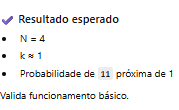

In [ ]:
#CENÁRIO 2
#16 qubits – 1 alvo (111...1)

n = 16
target = 2**16 - 1

qc, counts, tempo_q, k = grover_run(n, [target], shots=1000)

print("Iterações:", k)
print("Tempo quântico:", tempo_q)


Iterações: 201
Tempo quântico: 9.870808218000093


In [ ]:
#Busca clássica linear

def classical_search(n, target):
    t0 = time.perf_counter()
    for x in range(2**n):
        if x == target:
            break
    t1 = time.perf_counter()
    return t1 - t0

tempo_classico = classical_search(16, target)

print("Tempo clássico:", tempo_classico)


Tempo clássico: 0.007109049999598938


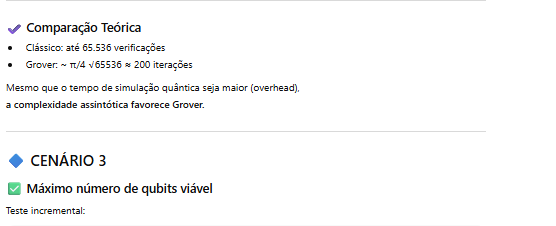

In [ ]:
#CENÁRIO 3 #Máximo número de qubits
for n in [18, 20, 22]:
    try:
        qc, counts, tempo, k = grover_run(n, [2**n - 1], shots=500)
        print(f"{n} qubits → tempo {tempo:.3f}s")
    except:
        print(f"{n} qubits falhou")




18 qubits → tempo 36.232s
20 qubits → tempo 216.724s
22 qubits → tempo 1746.780s


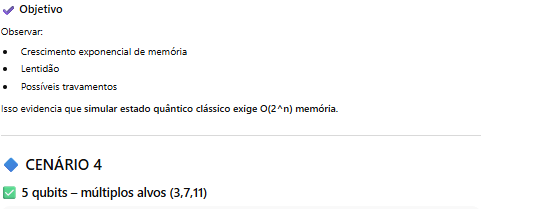

In [ ]:
"""#CENÁRIO 4
#5 qubits – múltiplos alvos (3,7,11)

n = 5
targets = [3,7,11]

qc, counts, tempo, k = grover_run(n, targets)

print("Iterações:", k)
print("Tempo:", tempo)
print(counts)
"""

'#CENÁRIO 4\n#5 qubits – múltiplos alvos (3,7,11)\n\nn = 5\ntargets = [3,7,11]\n\nqc, counts, tempo, k = grover_run(n, targets)\n\nprint("Iterações:", k)\nprint("Tempo:", tempo)\nprint(counts)\n'

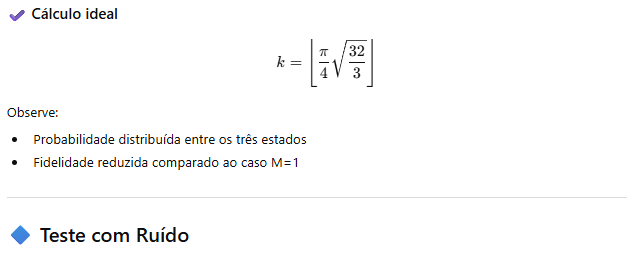

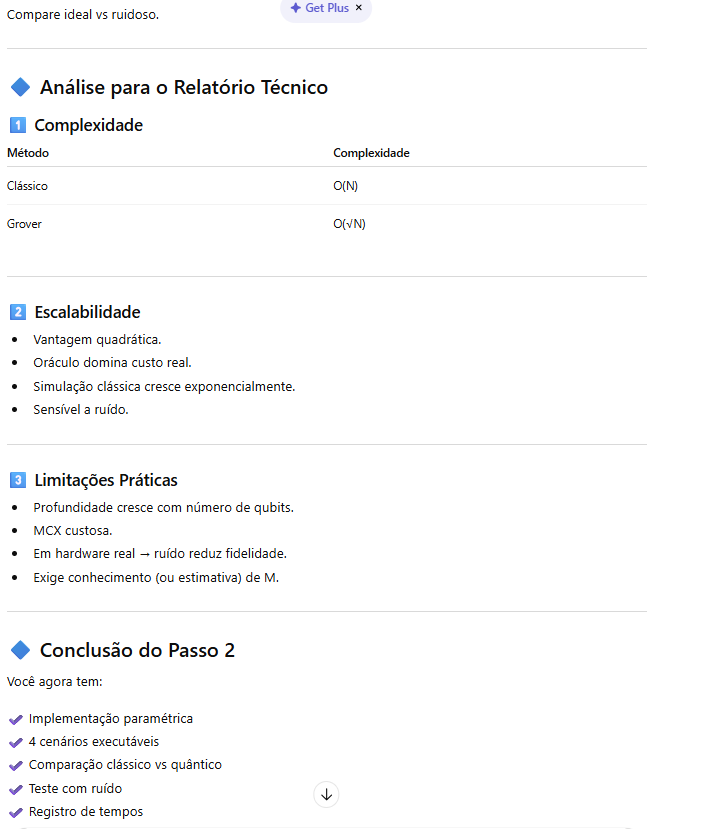


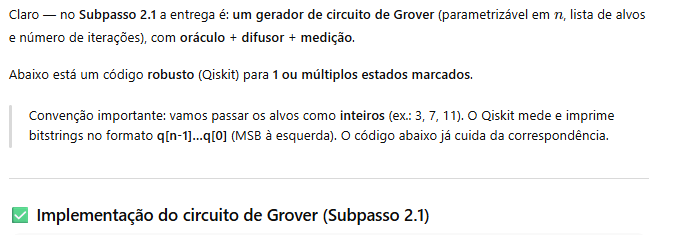

In [ ]:
import numpy as np
from qiskit import QuantumCircuit

def _int_to_bitstring(x: int, n: int) -> str:
    """Retorna bitstring MSB->LSB com n bits, ex.: n=5, x=3 => '00011'."""
    return format(x, f"0{n}b")

def apply_phase_oracle_for_targets(qc: QuantumCircuit, targets: list[int]):
    """
    Oráculo por fase:
      Uf|x> = -|x> se x em targets, senão Uf|x> = |x>.
    Implementa 'marcação' via multi-controlled-Z para cada alvo.
    """
    n = qc.num_qubits

    for t in targets:
        bits = _int_to_bitstring(t, n)  # MSB->LSB, ex.: '101'
        # Ajuste: qubit i é o bit LSB (bits[-1]) quando endereçamos qc.x(i)
        # Portanto, percorremos bits de LSB->MSB usando reversed(bits)
        for i, b in enumerate(reversed(bits)):
            if b == "0":
                qc.x(i)

        # Aplicar MCZ usando H + MCX + H no qubit alvo
        target = n - 1
        controls = list(range(n - 1))

        qc.h(target)
        if len(controls) == 0:
            qc.z(target)
        else:
            qc.mcx(controls, target)  # multi-controlled X
        qc.h(target)

        # Desfazer os X do mapeamento
        for i, b in enumerate(reversed(bits)):
            if b == "0":
                qc.x(i)

def apply_diffuser(qc: QuantumCircuit):
    """
    Difusor padrão (inversão em torno da média):
      D = 2|s><s| - I
    Implementação: H^n X^n (MCZ) X^n H^n
    """
    n = qc.num_qubits

    qc.h(range(n))
    qc.x(range(n))

    target = n - 1
    controls = list(range(n - 1))

    qc.h(target)
    if len(controls) == 0:
        qc.z(target)
    else:
        qc.mcx(controls, target)
    qc.h(target)

    qc.x(range(n))
    qc.h(range(n))

def grover_iterations_optimal(n: int, M: int) -> int:
    """
    k ~ floor(pi/4 * sqrt(N/M)), com N=2^n.
    """
    N = 2**n
    return int(np.floor((np.pi/4) * np.sqrt(N / M)))

def build_grover_circuit(n: int, targets: list[int], k: int | None = None, measure: bool = True):
    """
    Constrói o circuito de Grover para n qubits e lista de alvos (targets).
    - targets: lista de inteiros (estados marcados)
    - k: número de iterações (se None, usa k ótimo aproximado)
    """
    if len(targets) < 1:
        raise ValueError("targets deve conter pelo menos 1 estado marcado (M>=1).")

    # valida alvos no range
    N = 2**n
    for t in targets:
        if not (0 <= t < N):
            raise ValueError(f"Alvo {t} fora do intervalo [0, {N-1}].")

    M = len(targets)
    if k is None:
        k = grover_iterations_optimal(n, M)

    qc = QuantumCircuit(n, n if measure else 0)

    # 1) Estado uniforme |s>
    qc.h(range(n))

    # 2) Iterações de Grover
    for _ in range(k):
        apply_phase_oracle_for_targets(qc, targets)
        apply_diffuser(qc)

    # 3) Medição
    if measure:
        qc.measure(range(n), range(n))

    return qc, k


In [ ]:
#Teste rápido (para validar que o circuito está ok)
#Cenário 1: 2 qubits, alvo = 3 (|11⟩)

qc2, k2 = build_grover_circuit(n=2, targets=[3])
print("k =", k2)
print(qc2.draw("text"))



#Cenário 4: 5 qubits, alvos = 3, 7, 11
qc5, k5 = build_grover_circuit(n=5, targets=[3,7,11])
print("k =", k5)
print(qc5.draw("text"))


k = 1
     ┌───┐          ┌───┐┌───┐               ┌───┐┌───┐     ┌─┐   
q_0: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├─────┤M├───
     ├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤├───┤┌───┐└╥┘┌─┐
q_1: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─╫─┤M├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘ ║ └╥┘
c: 2/════════════════════════════════════════════════════════╩══╩═
                                                             0  1 
k = 2
     ┌───┐                                                                 »
q_0: ┤ H ├────────────■────────────────────────■────────────────────────■──»
     ├───┤            │                        │                        │  »
q_1: ┤ H ├────────────■────────────────────────■────────────────────────■──»
     ├───┤┌───┐       │  ┌───┐                 │  ┌───┐                 │  »
q_2: ┤ H ├┤ X ├───────■──┤ X ├─────────────────■──┤ X ├─────────────────■──»
     ├───┤├───┤       │  ├───┤┌───┐            │  ├───┤  

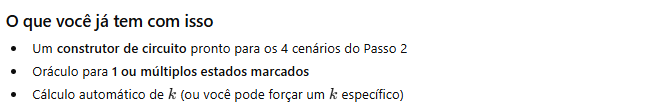

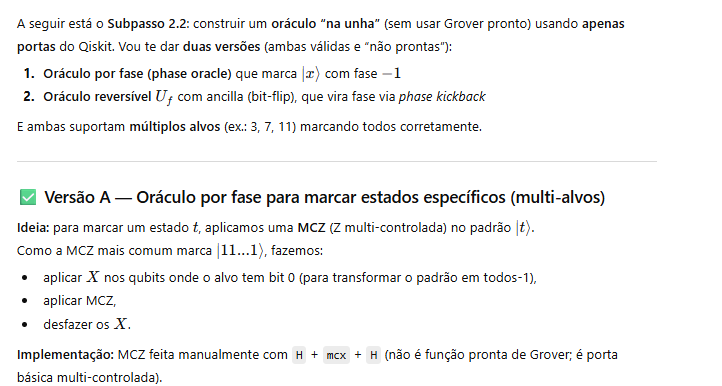

In [ ]:
from qiskit import QuantumCircuit

def int_to_bitstring(t: int, n: int) -> str:
    return format(t, f"0{n}b")  # MSB -> LSB

def oracle_phase_mark_targets(qc: QuantumCircuit, targets: list[int]):
    """
    Oráculo por fase:
      |x> -> -|x> se x está em targets; caso contrário, |x> -> |x>

    Marca cada alvo individualmente usando:
      X (para alinhar zeros) + MCZ + X (desfaz)
    """
    n = qc.num_qubits
    N = 2**n

    # validação simples
    for t in targets:
        if not (0 <= t < N):
            raise ValueError(f"Alvo {t} fora do intervalo [0, {N-1}]")

    for t in targets:
        bits = int_to_bitstring(t, n)  # MSB->LSB

        # 1) Alinhar: transformar |t> em |11..1> via X onde bit==0
        # Qiskit: qubit 0 é LSB, então percorremos bits ao contrário (LSB->MSB)
        for qi, b in enumerate(reversed(bits)):
            if b == "0":
                qc.x(qi)

        # 2) Aplicar MCZ:
        # MCZ = H(target) -> MCX(controls,target) -> H(target)
        target_qubit = n - 1
        control_qubits = list(range(n - 1))

        qc.h(target_qubit)
        if len(control_qubits) == 0:
            qc.z(target_qubit)
        else:
            qc.mcx(control_qubits, target_qubit)  # multi-controlled-X
        qc.h(target_qubit)

        # 3) Desfazer alinhamento
        for qi, b in enumerate(reversed(bits)):
            if b == "0":
                qc.x(qi)


In [ ]:
#Como usar (exemplo rápido)
n = 5
targets = [3, 7, 11]
qc = QuantumCircuit(n)
oracle_phase_mark_targets(qc, targets)
print(qc.draw("text"))


                                                                           »
q_0: ────────────■────────────────────────■────────────────────────■───────»
                 │                        │                        │       »
q_1: ────────────■────────────────────────■────────────────────────■───────»
     ┌───┐       │  ┌───┐                 │  ┌───┐                 │  ┌───┐»
q_2: ┤ X ├───────■──┤ X ├─────────────────■──┤ X ├─────────────────■──┤ X ├»
     ├───┤       │  ├───┤┌───┐            │  ├───┤                 │  └───┘»
q_3: ┤ X ├───────■──┤ X ├┤ X ├────────────■──┤ X ├─────────────────■───────»
     ├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤┌───┐┌───┐┌───┐┌─┴─┐┌───┐»
q_4: ┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ X ├┤ H ├┤ X ├┤ H ├»
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«          
«q_0: ─────
«          
«q_1: ─────
«          
«q_2: ─────
«          
«q_3: ─────
«     ┌───┐
«q_4: ┤ X ├
«     └───┘


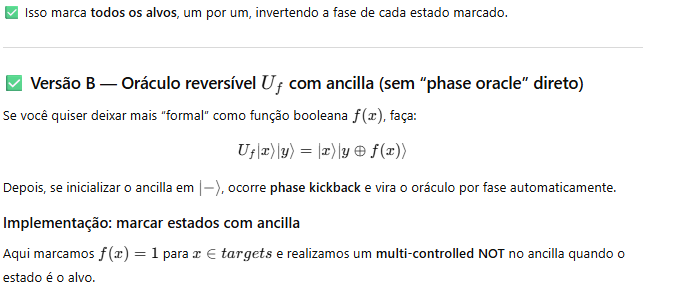

In [ ]:
def oracle_bitflip_with_ancilla(qc: QuantumCircuit, targets: list[int], anc: int):
    """
    Implementa Uf: |x>|y> -> |x>|y xor f(x)>
    onde f(x)=1 se x in targets.

    anc: índice do qubit ancilla (deve existir no circuito).
    """
    n_total = qc.num_qubits
    n = n_total - 1  # assumindo 1 ancilla
    N = 2**n

    for t in targets:
        if not (0 <= t < N):
            raise ValueError(f"Alvo {t} fora do intervalo [0, {N-1}]")

    for t in targets:
        bits = int_to_bitstring(t, n)

        # alinhar zeros no registrador de dados (qubits 0..n-1)
        for qi, b in enumerate(reversed(bits)):
            if b == "0":
                qc.x(qi)

        # MCX no ancilla controlado por todos os qubits de dados
        controls = list(range(n))
        qc.mcx(controls, anc)

        # desfazer alinhamento
        for qi, b in enumerate(reversed(bits)):
            if b == "0":
                qc.x(qi)


In [ ]:
#Como usar com phase kickback

n = 5
targets = [3, 7, 11]

qc = QuantumCircuit(n+1)      # +1 ancilla
anc = n

# preparar ancilla em |-> = H X |0>
qc.x(anc)
qc.h(anc)

# preparar superposição nos qubits de dados
qc.h(range(n))

# aplicar oráculo Uf
oracle_bitflip_with_ancilla(qc, targets, anc)

print(qc.draw("text"))


     ┌───┐                                             
q_0: ┤ H ├───────■──────────────■──────────────■───────
     ├───┤       │              │              │       
q_1: ┤ H ├───────■──────────────■──────────────■───────
     ├───┤┌───┐  │  ┌───┐       │  ┌───┐       │  ┌───┐
q_2: ┤ H ├┤ X ├──■──┤ X ├───────■──┤ X ├───────■──┤ X ├
     ├───┤├───┤  │  ├───┤┌───┐  │  ├───┤       │  └───┘
q_3: ┤ H ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├───────■───────
     ├───┤├───┤  │  ├───┤├───┤  │  ├───┤┌───┐  │  ┌───┐
q_4: ┤ H ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├
     ├───┤├───┤┌─┴─┐└───┘└───┘┌─┴─┐└───┘└───┘┌─┴─┐└───┘
q_5: ┤ X ├┤ H ├┤ X ├──────────┤ X ├──────────┤ X ├─────
     └───┘└───┘└───┘          └───┘          └───┘     


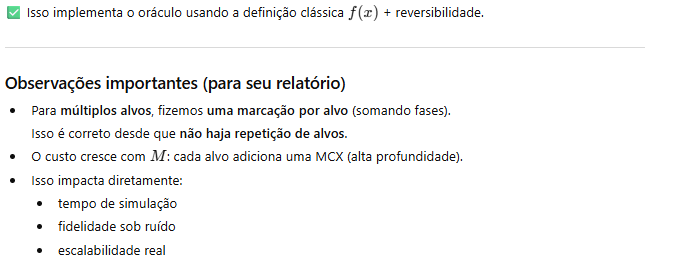

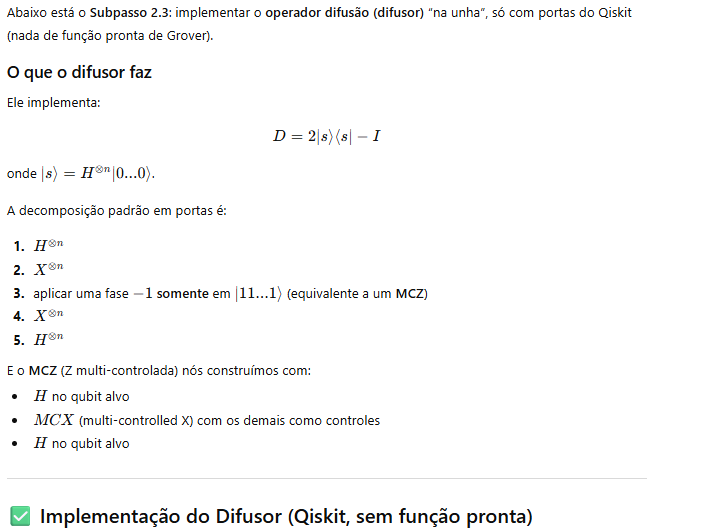

In [ ]:
from qiskit import QuantumCircuit

def diffuser_operator(qc: QuantumCircuit):
    """
    Aplica o operador difusão D = 2|s><s| - I no registrador do circuito qc.
    Implementação padrão:
      H^n X^n (MCZ) X^n H^n
    MCZ é implementado como: H(target) MCX(controls,target) H(target)
    """
    n = qc.num_qubits

    # 1) H^n
    qc.h(range(n))

    # 2) X^n
    qc.x(range(n))

    # 3) MCZ em |11...1>
    target = n - 1
    controls = list(range(n - 1))

    qc.h(target)
    if len(controls) == 0:
        qc.z(target)
    else:
        qc.mcx(controls, target)  # Multi-controlled X
    qc.h(target)

    # 4) X^n
    qc.x(range(n))

    # 5) H^n
    qc.h(range(n))


In [ ]:
#Teste rápido (visualizar difusor isolado)

n = 3
qc = QuantumCircuit(n)
diffuser_operator(qc)
print(qc.draw("text"))


     ┌───┐┌───┐          ┌───┐┌───┐     
q_0: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_1: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐
q_2: ┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘


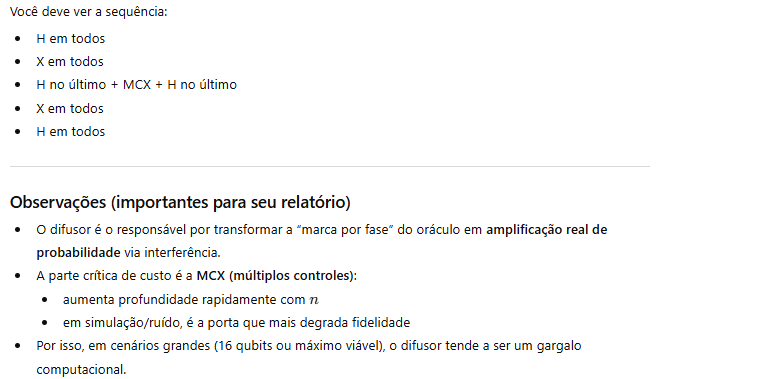


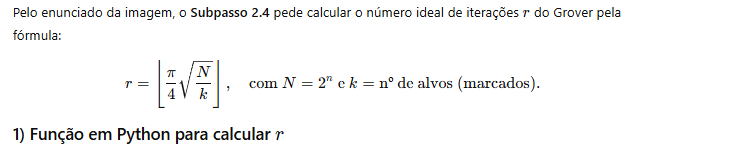

In [ ]:
import math

def grover_r_ideal(n: int, k: int) -> int:
    if k <= 0:
        raise ValueError("k (número de alvos) deve ser >= 1")
    N = 2**n
    return math.floor((math.pi/4) * math.sqrt(N / k))


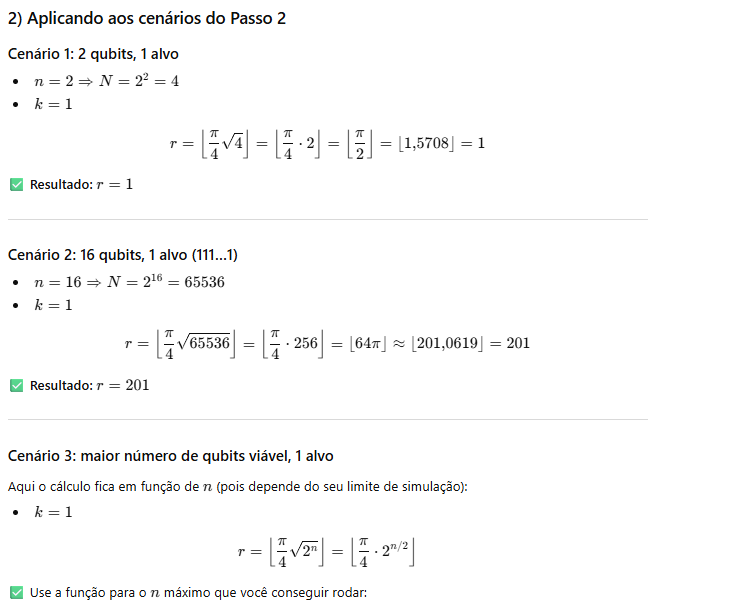

In [ ]:
for n in [18, 20, 22, 24]:
    print(n, grover_r_ideal(n, 1))


18 402
20 804
22 1608
24 3216


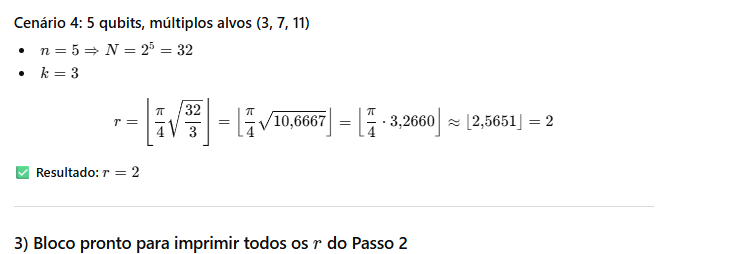

In [ ]:
print("Cenário 1 (n=2, k=1):", grover_r_ideal(2, 1))
print("Cenário 2 (n=16, k=1):", grover_r_ideal(16, 1))
print("Cenário 4 (n=5, k=3):", grover_r_ideal(5, 3))


Cenário 1 (n=2, k=1): 1
Cenário 2 (n=16, k=1): 201
Cenário 4 (n=5, k=3): 2


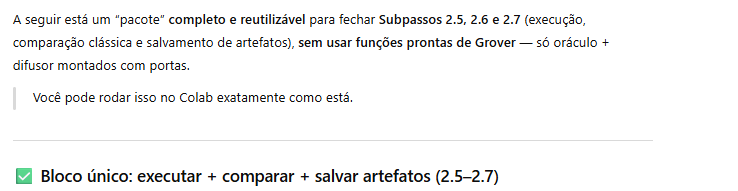

In [ ]:
import math
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error


# -------------------------
# 2.2 ORÁCULO (fase) – multi-alvos
# -------------------------
def int_to_bitstring(t: int, n: int) -> str:
    return format(t, f"0{n}b")  # MSB -> LSB

def oracle_phase_mark_targets(qc: QuantumCircuit, targets: list[int]):
    """
    Uf|x> = -|x> se x em targets; Uf|x> = |x> caso contrário.
    Implementação: X (alinhamento) + MCZ + X (desfaz), para cada alvo.
    """
    n = qc.num_qubits
    N = 2**n

    for t in targets:
        if not (0 <= t < N):
            raise ValueError(f"Alvo {t} fora do intervalo [0, {N-1}]")

    for t in targets:
        bits = int_to_bitstring(t, n)

        # alinhar zeros: qubit 0 é LSB => percorre bits ao contrário
        for qi, b in enumerate(reversed(bits)):
            if b == "0":
                qc.x(qi)

        # MCZ em |11..1| via H + MCX + H
        target = n - 1
        controls = list(range(n - 1))

        qc.h(target)
        if len(controls) == 0:
            qc.z(target)
        else:
            qc.mcx(controls, target)
        qc.h(target)

        # desfazer alinhamento
        for qi, b in enumerate(reversed(bits)):
            if b == "0":
                qc.x(qi)


# -------------------------
# 2.3 DIFUSOR (difusão)
# -------------------------
def diffuser_operator(qc: QuantumCircuit):
    """
    D = 2|s><s| - I
    Implementação: H^n X^n (MCZ) X^n H^n
    """
    n = qc.num_qubits

    qc.h(range(n))
    qc.x(range(n))

    target = n - 1
    controls = list(range(n - 1))

    qc.h(target)
    if len(controls) == 0:
        qc.z(target)
    else:
        qc.mcx(controls, target)
    qc.h(target)

    qc.x(range(n))
    qc.h(range(n))


# -------------------------
# 2.4 Número ideal de iterações r
# -------------------------
def grover_r_ideal(n: int, k: int) -> int:
    if k <= 0:
        raise ValueError("k (número de alvos) deve ser >= 1")
    N = 2**n
    return math.floor((math.pi/4) * math.sqrt(N / k))


# -------------------------
# Montar circuito de Grover (sem 'Grover pronto')
# -------------------------
def build_grover_circuit(n: int, targets: list[int], r: int | None = None, measure=True) -> tuple[QuantumCircuit, int]:
    if r is None:
        r = grover_r_ideal(n, len(targets))

    qc = QuantumCircuit(n, n if measure else 0)

    # superposição uniforme
    qc.h(range(n))

    # r iterações
    for _ in range(r):
        oracle_phase_mark_targets(qc, targets)
        diffuser_operator(qc)

    # medida
    if measure:
        qc.measure(range(n), range(n))

    return qc, r


# -------------------------
# Executar circuito (ideal ou com ruído)
# -------------------------
def run_quantum(qc: QuantumCircuit, shots=2000, noise=False):
    if not noise:
        sim = AerSimulator()
    else:
        # ruído simples (ajuste se quiser)
        noise_model = NoiseModel()
        noise_model.add_all_qubit_quantum_error(depolarizing_error(0.002, 1), ['h', 'x'])
        # mcx normalmente decompõe, mas manteremos um ruído 2q em cx como proxy
        noise_model.add_all_qubit_quantum_error(depolarizing_error(0.01, 2), ['cx'])
        sim = AerSimulator(noise_model=noise_model)

    t0 = time.perf_counter()
    result = sim.run(qc, shots=shots).result()
    t1 = time.perf_counter()

    counts = result.get_counts()
    return counts, (t1 - t0)


# -------------------------
# Histograma (matplotlib puro) + salvar
# -------------------------
def save_histogram(counts: dict, filename: str, title: str):
    labels = list(counts.keys())
    values = [counts[k] for k in labels]

    plt.figure()
    plt.bar(labels, values)
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel("Bitstring (q[n-1]...q[0])")
    plt.ylabel("Counts")
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()


# -------------------------
# Probabilidade de sucesso: soma das contagens dos alvos
# -------------------------
def success_probability(counts: dict, n: int, targets: list[int]) -> float:
    target_bits = {int_to_bitstring(t, n) for t in targets}  # MSB->LSB
    total = sum(counts.values())
    hit = sum(v for k, v in counts.items() if k in target_bits)
    return hit / total if total else 0.0


# -------------------------
# 2.6 Busca clássica linear (tempo + iterações)
# -------------------------
def classical_linear_search(n: int, target: int):
    N = 2**n
    t0 = time.perf_counter()
    iters = 0
    found = None
    for x in range(N):
        iters += 1
        if x == target:
            found = x
            break
    t1 = time.perf_counter()
    return found, iters, (t1 - t0)


# -------------------------
# 2.7 Salvar artefatos (circuito + contagens + resumo)
# -------------------------
def save_artifacts(prefix: str, qc: QuantumCircuit, counts: dict, meta: dict):
    # salvar circuito em texto
    with open(f"{prefix}_circuit.txt", "w", encoding="utf-8") as f:
        f.write(qc.draw("text").single_string())

    # salvar contagens
    with open(f"{prefix}_counts.json", "w", encoding="utf-8") as f:
        json.dump(counts, f, indent=2)

    # salvar metadados
    with open(f"{prefix}_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    print(f"Artefatos salvos: {prefix}_circuit.txt, {prefix}_counts.json, {prefix}_meta.json")


# -------------------------
# Função principal (2.5 + 2.6 + 2.7)
# -------------------------
def run_experiment(n: int, targets: list[int], shots=2000, noise=False, do_classical=True, prefix="grover"):
    qc, r = build_grover_circuit(n, targets, r=None, measure=True)

    # 2.5 executar
    counts, t_quant = run_quantum(qc, shots=shots, noise=noise)
    p_succ = success_probability(counts, n, targets)

    print("\n--- QUÂNTICO ---")
    print(f"n={n}, alvos={targets}, k={len(targets)}")
    print(f"r (iterações) = {r}")
    print(f"tempo_quântico = {t_quant:.6f} s")
    print(f"prob_sucesso (soma alvos) = {p_succ:.4f}")

    # histograma + salvar
    hist_file = f"{prefix}_n{n}_k{len(targets)}_{'noisy' if noise else 'ideal'}_hist.png"
    save_histogram(counts, hist_file, f"Grover n={n}, k={len(targets)}, r={r} ({'ruído' if noise else 'ideal'})")

    # 2.6 clássico
    classic = None
    if do_classical:
        if len(targets) != 1:
            print("\n(Clássico) comparação linear implementada para 1 alvo. Para múltiplos, escolha um alvo específico.")
        else:
            found, iters, t_class = classical_linear_search(n, targets[0])
            classic = {"found": found, "iters": iters, "time_s": t_class}
            print("\n--- CLÁSSICO (busca linear) ---")
            print(f"tempo_clássico = {t_class:.6f} s")
            print(f"iterações_clássicas = {iters}")

    # 2.7 salvar artefatos
    meta = {
        "n": n,
        "targets": targets,
        "k": len(targets),
        "r": r,
        "shots": shots,
        "noise": noise,
        "time_quantum_s": t_quant,
        "success_probability": p_succ,
        "classic": classic,
        "histogram_file": hist_file
    }

    prefix_full = f"{prefix}_n{n}_k{len(targets)}_{'noisy' if noise else 'ideal'}"
    save_artifacts(prefix_full, qc, counts, meta)

    # imprimir circuito (registro)
    print("\n--- CIRCUITO (texto) ---")
    print(qc.draw("text"))

    return qc, counts, meta



--- QUÂNTICO ---
n=2, alvos=[3], k=1
r (iterações) = 1
tempo_quântico = 0.031111 s
prob_sucesso (soma alvos) = 1.0000


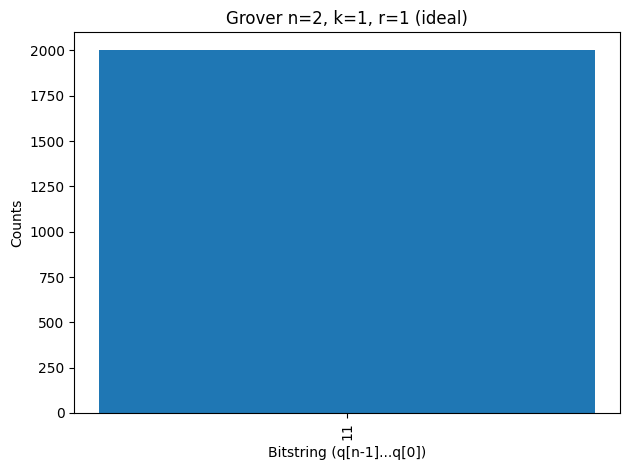


--- CLÁSSICO (busca linear) ---
tempo_clássico = 0.000004 s
iterações_clássicas = 4
Artefatos salvos: C1_n2_k1_ideal_circuit.txt, C1_n2_k1_ideal_counts.json, C1_n2_k1_ideal_meta.json

--- CIRCUITO (texto) ---
     ┌───┐          ┌───┐┌───┐               ┌───┐┌───┐     ┌─┐   
q_0: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├─────┤M├───
     ├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤├───┤┌───┐└╥┘┌─┐
q_1: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─╫─┤M├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘ ║ └╥┘
c: 2/════════════════════════════════════════════════════════╩══╩═
                                                             0  1 


(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x79612d0d7e30>,
 {'11': 2000},
 {'n': 2,
  'targets': [3],
  'k': 1,
  'r': 1,
  'shots': 2000,
  'noise': False,
  'time_quantum_s': 0.031111071999475826,
  'success_probability': 1.0,
  'classic': {'found': 3, 'iters': 4, 'time_s': 3.7599993447656743e-06},
  'histogram_file': 'C1_n2_k1_ideal_hist.png'})

In [ ]:
#Executar agora (exemplos recomendados)
#Cenário 1 (2 qubits, 1 alvo)

run_experiment(n=2, targets=[3], shots=2000, noise=False, do_classical=True, prefix="C1")



--- QUÂNTICO ---
n=16, alvos=[65535], k=1
r (iterações) = 201
tempo_quântico = 2.787903 s
prob_sucesso (soma alvos) = 1.0000


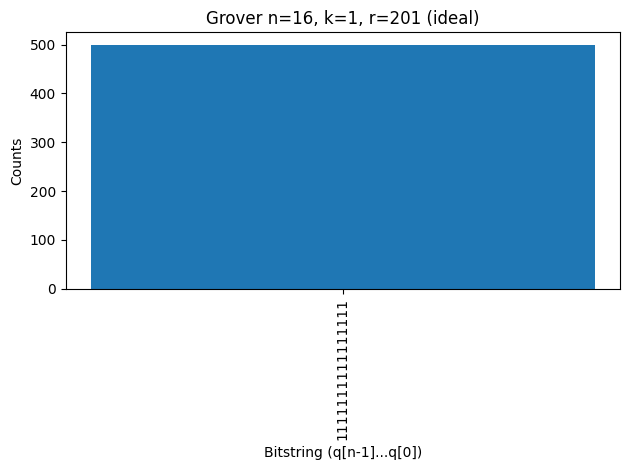

Streaming output truncated to the last 5000 lines.
« q_2: ┤ X ├┤ H ├────────────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────────»
«      ├───┤├───┤            │  ├───┤├───┤            │  ├───┤├───┤          »
« q_3: ┤ X ├┤ H ├────────────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────────»
«      ├───┤├───┤            │  ├───┤├───┤            │  ├───┤├───┤          »
« q_4: ┤ X ├┤ H ├────────────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────────»
«      ├───┤├───┤            │  ├───┤├───┤            │  ├───┤├───┤          »
« q_5: ┤ X ├┤ H ├────────────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────────»
«      ├───┤├───┤            │  ├───┤├───┤            │  ├───┤├───┤          »
« q_6: ┤ X ├┤ H ├────────────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────────»
«      ├───┤├───┤            │  ├───┤├───┤            │  ├───┤├───┤          »
« q_7: ┤ X ├┤ H ├────────────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────────»
«      ├───┤├───┤            │  ├───┤├───┤            │  ├───┤├───┤          »
«

(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x79612d0e6060>,
 {'1111111111111111': 500},
 {'n': 16,
  'targets': [65535],
  'k': 1,
  'r': 201,
  'shots': 500,
  'noise': False,
  'time_quantum_s': 2.787903018000179,
  'success_probability': 1.0,
  'classic': {'found': 65535, 'iters': 65536, 'time_s': 0.0037628170002790284},
  'histogram_file': 'C2_n16_k1_ideal_hist.png'})

In [ ]:
#Cenário 2 (16 qubits, 1 alvo = 2^16-1)
#Observação: simulação com shots menores ajuda a não demorar demais.

run_experiment(n=16, targets=[2**16 - 1], shots=500, noise=False, do_classical=True, prefix="C2")



--- QUÂNTICO ---
n=5, alvos=[3, 7, 11], k=3
r (iterações) = 2
tempo_quântico = 0.015107 s
prob_sucesso (soma alvos) = 0.9995


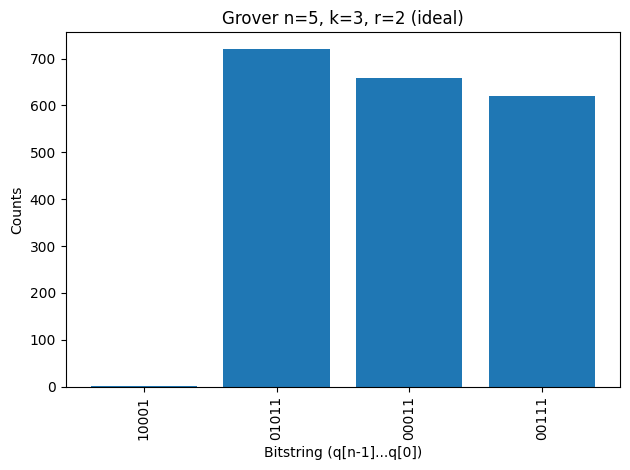

Artefatos salvos: C4_n5_k3_ideal_circuit.txt, C4_n5_k3_ideal_counts.json, C4_n5_k3_ideal_meta.json

--- CIRCUITO (texto) ---
     ┌───┐                                                                 »
q_0: ┤ H ├────────────■────────────────────────■────────────────────────■──»
     ├───┤            │                        │                        │  »
q_1: ┤ H ├────────────■────────────────────────■────────────────────────■──»
     ├───┤┌───┐       │  ┌───┐                 │  ┌───┐                 │  »
q_2: ┤ H ├┤ X ├───────■──┤ X ├─────────────────■──┤ X ├─────────────────■──»
     ├───┤├───┤       │  ├───┤┌───┐            │  ├───┤                 │  »
q_3: ┤ H ├┤ X ├───────■──┤ X ├┤ X ├────────────■──┤ X ├─────────────────■──»
     ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤┌───┐┌───┐┌───┐┌─┴─┐»
q_4: ┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ X ├┤ H ├┤ X ├»
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
c: 5/═══════════════════════

(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x796127448e60>,
 {'10001': 1, '01011': 720, '00011': 659, '00111': 620},
 {'n': 5,
  'targets': [3, 7, 11],
  'k': 3,
  'r': 2,
  'shots': 2000,
  'noise': False,
  'time_quantum_s': 0.015106629000001703,
  'success_probability': 0.9995,
  'classic': None,
  'histogram_file': 'C4_n5_k3_ideal_hist.png'})

In [ ]:
#Cenário 4 (5 qubits, múltiplos alvos: 3, 7, 11)
#(Aqui a comparação clássica “1 alvo” não se aplica diretamente; você pode rodar clássico para um alvo específico se quiser.)

run_experiment(n=5, targets=[3,7,11], shots=2000, noise=False, do_classical=False, prefix="C4")



--- QUÂNTICO ---
n=5, alvos=[3], k=1
r (iterações) = 4
tempo_quântico = 0.793709 s
prob_sucesso (soma alvos) = 0.8710


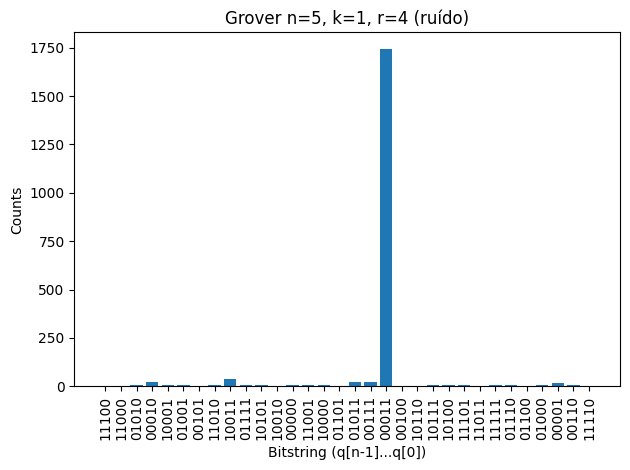


--- CLÁSSICO (busca linear) ---
tempo_clássico = 0.000002 s
iterações_clássicas = 4
Artefatos salvos: C1_noise_n5_k1_noisy_circuit.txt, C1_noise_n5_k1_noisy_counts.json, C1_noise_n5_k1_noisy_meta.json

--- CIRCUITO (texto) ---
     ┌───┐               ┌───┐┌───┐                    ┌───┐┌───┐          »
q_0: ┤ H ├────────────■──┤ H ├┤ X ├─────────────────■──┤ X ├┤ H ├──────────»
     ├───┤            │  ├───┤├───┤                 │  ├───┤├───┤          »
q_1: ┤ H ├────────────■──┤ H ├┤ X ├─────────────────■──┤ X ├┤ H ├──────────»
     ├───┤┌───┐       │  ├───┤├───┤┌───┐            │  ├───┤├───┤┌───┐     »
q_2: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├────────────■──┤ X ├┤ H ├┤ X ├─────»
     ├───┤├───┤       │  ├───┤├───┤├───┤            │  ├───┤├───┤├───┤     »
q_3: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├────────────■──┤ X ├┤ H ├┤ X ├─────»
     ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤├───┤├───┤┌───┐»
q_4: ┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├»
  

(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x79613416f290>,
 {'11100': 2,
  '11000': 2,
  '01010': 6,
  '00010': 25,
  '10001': 6,
  '01001': 8,
  '00101': 4,
  '11010': 6,
  '10011': 39,
  '01111': 6,
  '10101': 6,
  '10010': 3,
  '00000': 7,
  '11001': 6,
  '10000': 8,
  '01101': 3,
  '01011': 23,
  '00111': 24,
  '00011': 1742,
  '00100': 4,
  '10110': 4,
  '10111': 5,
  '10100': 5,
  '11101': 5,
  '11011': 4,
  '11111': 6,
  '01110': 6,
  '01100': 1,
  '01000': 7,
  '00001': 17,
  '00110': 7,
  '11110': 3},
 {'n': 5,
  'targets': [3],
  'k': 1,
  'r': 4,
  'shots': 2000,
  'noise': True,
  'time_quantum_s': 0.793709200000194,
  'success_probability': 0.871,
  'classic': {'found': 3, 'iters': 4, 'time_s': 1.7370002751704305e-06},
  'histogram_file': 'C1_noise_n5_k1_noisy_hist.png'})

In [ ]:
#Opcional) repetir com ruído
run_experiment(n=5, targets=[3], shots=2000, noise=True, do_classical=True, prefix="C1_noise")


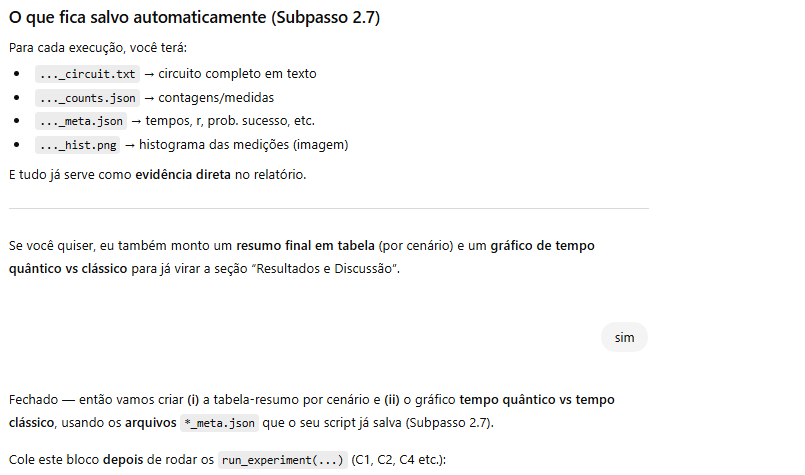

In [ ]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt

def load_all_metas(pattern="*_meta.json"):
    rows = []
    for path in sorted(glob.glob(pattern)):
        with open(path, "r", encoding="utf-8") as f:
            meta = json.load(f)

        row = {
            "arquivo": path,
            "n": meta["n"],
            "k_alvos": meta["k"],
            "alvos": str(meta["targets"]),
            "r_iteracoes_grover": meta["r"],
            "shots": meta["shots"],
            "ruido": meta["noise"],
            "tempo_quantico_s": meta["time_quantum_s"],
            "prob_sucesso": meta["success_probability"],
            "histograma_png": meta["histogram_file"],
        }

        classic = meta.get("classic")
        if classic:
            row["tempo_classico_s"] = classic.get("time_s", None)
            row["iters_classico"] = classic.get("iters", None)
        else:
            row["tempo_classico_s"] = None
            row["iters_classico"] = None

        rows.append(row)

    df = pd.DataFrame(rows)
    return df

df = load_all_metas("*_meta.json")
df_sorted = df.sort_values(["n", "k_alvos", "ruido"]).reset_index(drop=True)

display(df_sorted)  # no Colab mostra a tabela bonitinha


,arquivo,n,k_alvos,alvos,r_iteracoes_grover,shots,ruido,tempo_quantico_s,prob_sucesso,histograma_png,tempo_classico_s,iters_classico
0,C1_n2_k1_ideal_meta.json,2,1,[3],1,2000,False,0.031111,1.0000,C1_n2_k1_ideal_hist.png,0.000004,4.0
1,C1_noise_n5_k1_noisy_meta.json,5,1,[3],4,2000,True,0.793709,0.8710,C1_noise_n5_k1_noisy_hist.png,0.000002,4.0
2,C4_n5_k3_ideal_meta.json,5,3,"[3, 7, 11]",2,2000,False,0.015107,0.9995,C4_n5_k3_ideal_hist.png,NaN,NaN
3,C2_n16_k1_ideal_meta.json,16,1,[65535],201,500,False,2.787903,1.0000,C2_n16_k1_ideal_hist.png,0.003763,65536.0


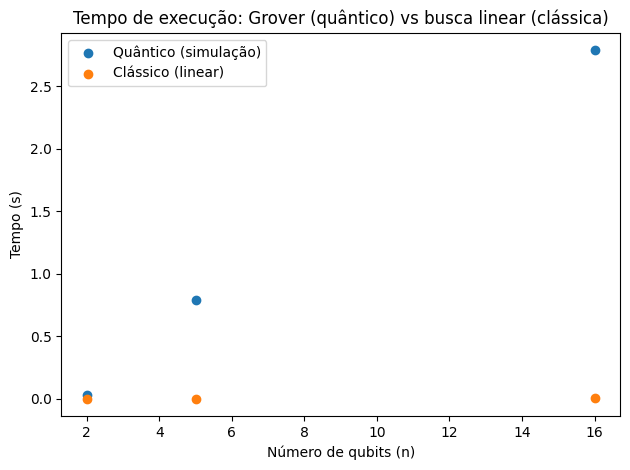

In [ ]:
#1) Gráfico: tempo quântico vs clássico (apenas onde houver clássico)

df_plot = df_sorted.dropna(subset=["tempo_classico_s"]).copy()

plt.figure()
plt.scatter(df_plot["n"], df_plot["tempo_quantico_s"], label="Quântico (simulação)")
plt.scatter(df_plot["n"], df_plot["tempo_classico_s"], label="Clássico (linear)")
plt.xlabel("Número de qubits (n)")
plt.ylabel("Tempo (s)")
plt.title("Tempo de execução: Grover (quântico) vs busca linear (clássica)")
plt.legend()
plt.tight_layout()
plt.show()


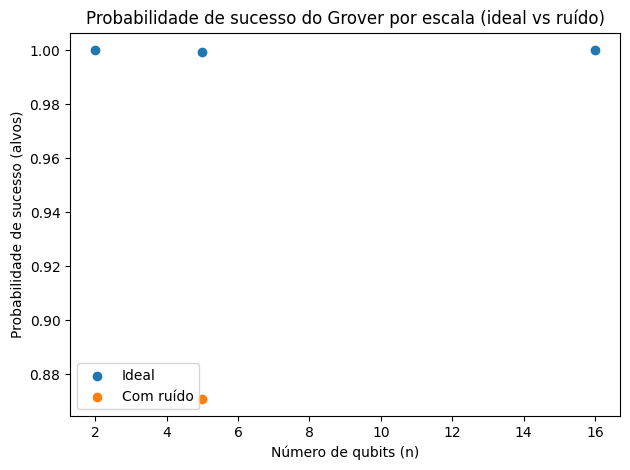

In [ ]:
#2) (Opcional) Gráfico: probabilidade de sucesso vs n (ideal/ruído)

plt.figure()
for noise_flag, group in df_sorted.groupby("ruido"):
    plt.scatter(group["n"], group["prob_sucesso"], label=f"{'Com ruído' if noise_flag else 'Ideal'}")
plt.xlabel("Número de qubits (n)")
plt.ylabel("Probabilidade de sucesso (alvos)")
plt.title("Probabilidade de sucesso do Grover por escala (ideal vs ruído)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#3) Exportar a tabela para CSV (pra colar no relatório)

df_sorted.to_csv("resumo_resultados_grover.csv", index=False)
print("Salvo: resumo_resultados_grover.csv")


Salvo: resumo_resultados_grover.csv


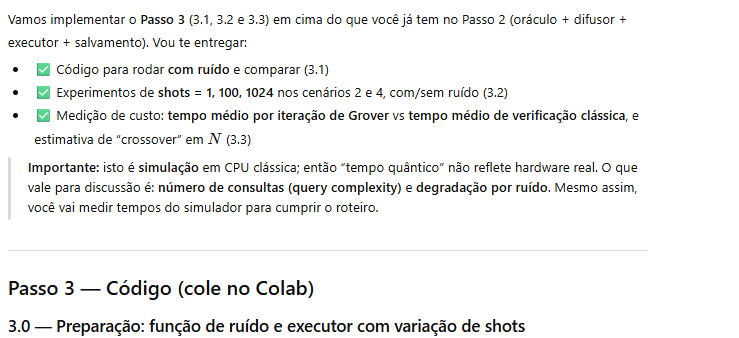

In [ ]:
import numpy as np
import time
import math
import json
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error


# ======= Reutilizando seu oráculo + difusor (do Passo 2) =======
def int_to_bitstring(t: int, n: int) -> str:
    return format(t, f"0{n}b")

def oracle_phase_mark_targets(qc: QuantumCircuit, targets: list[int]):
    n = qc.num_qubits
    N = 2**n
    for t in targets:
        if not (0 <= t < N):
            raise ValueError(f"Alvo {t} fora de [0,{N-1}]")

    for t in targets:
        bits = int_to_bitstring(t, n)
        for qi, b in enumerate(reversed(bits)):  # LSB->MSB
            if b == "0":
                qc.x(qi)

        target = n - 1
        controls = list(range(n - 1))

        qc.h(target)
        if len(controls) == 0:
            qc.z(target)
        else:
            qc.mcx(controls, target)
        qc.h(target)

        for qi, b in enumerate(reversed(bits)):
            if b == "0":
                qc.x(qi)

def diffuser_operator(qc: QuantumCircuit):
    n = qc.num_qubits
    qc.h(range(n))
    qc.x(range(n))

    target = n - 1
    controls = list(range(n - 1))

    qc.h(target)
    if len(controls) == 0:
        qc.z(target)
    else:
        qc.mcx(controls, target)
    qc.h(target)

    qc.x(range(n))
    qc.h(range(n))

def grover_r_ideal(n: int, k: int) -> int:
    N = 2**n
    return math.floor((math.pi/4) * math.sqrt(N / k))

def build_grover_circuit(n: int, targets: list[int], r: int | None = None, measure=True):
    if r is None:
        r = grover_r_ideal(n, len(targets))
    qc = QuantumCircuit(n, n if measure else 0)
    qc.h(range(n))
    for _ in range(r):
        oracle_phase_mark_targets(qc, targets)
        diffuser_operator(qc)
    if measure:
        qc.measure(range(n), range(n))
    return qc, r


# ======= Modelo de ruído controlável =======
def make_noise_model(p1=0.002, p2=0.01):
    """
    Ruído simples:
    - depolarizing 1-qubit em H/X
    - depolarizing 2-qubit em CX (proxy para decomposições que usam CX)
    """
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ['h', 'x'])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ['cx'])
    return nm


# ======= Execução =======
def run_counts(qc: QuantumCircuit, shots=1024, noise_model: NoiseModel | None = None):
    sim = AerSimulator(noise_model=noise_model) if noise_model else AerSimulator()
    t0 = time.perf_counter()
    res = sim.run(qc, shots=shots).result()
    t1 = time.perf_counter()
    counts = res.get_counts()
    return counts, (t1 - t0)

def success_probability(counts: dict, n: int, targets: list[int]) -> float:
    good = {int_to_bitstring(t, n) for t in targets}
    total = sum(counts.values())
    hit = sum(v for k, v in counts.items() if k in good)
    return hit / total if total else 0.0

def plot_counts(counts: dict, title: str, top=20):
    # Mostra apenas top-N barras para não ficar ilegível em 16 qubits
    items = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:top]
    labels = [k for k,_ in items]
    values = [v for _,v in items]
    plt.figure()
    plt.bar(labels, values)
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel("Bitstring")
    plt.ylabel("Counts")
    plt.tight_layout()
    plt.show()


=== 3.1 Impacto do ruído ===
r = 4
Ideal: tempo=0.0073s | P(sucesso)=1.0000
Ruído: tempo=0.4002s | P(sucesso)=0.8096


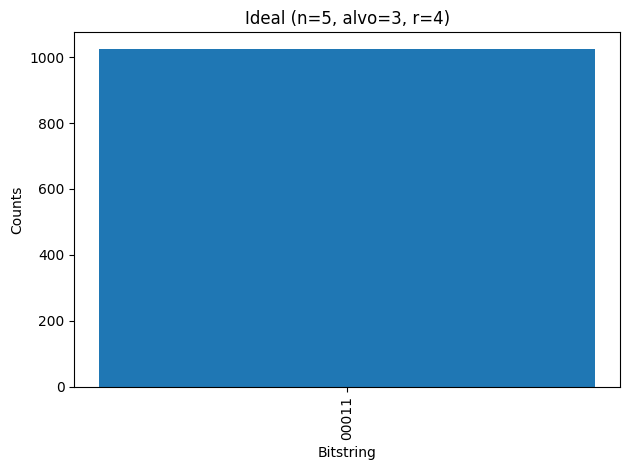

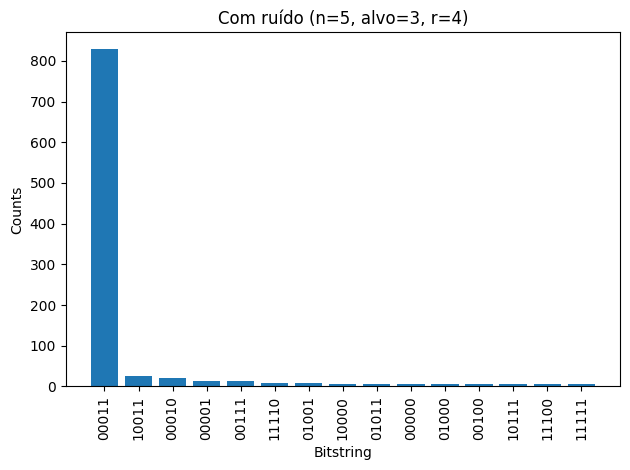

In [ ]:
#Subpasso 3.1 — Impacto do ruído (rodar 1 circuito com e sem ruído)
#Vamos usar um circuito “bom para ver diferença”: 5 qubits, 1 alvo (ou o cenário 4 com múltiplos alvos também funciona).

n = 5
targets = [3]   # um alvo

qc, r = build_grover_circuit(n, targets)

# Ideal
counts_ideal, t_ideal = run_counts(qc, shots=1024, noise_model=None)
p_ideal = success_probability(counts_ideal, n, targets)

# Com ruído
nm = make_noise_model(p1=0.003, p2=0.02)
counts_noisy, t_noisy = run_counts(qc, shots=1024, noise_model=nm)
p_noisy = success_probability(counts_noisy, n, targets)

print("=== 3.1 Impacto do ruído ===")
print(f"r = {r}")
print(f"Ideal: tempo={t_ideal:.4f}s | P(sucesso)={p_ideal:.4f}")
print(f"Ruído: tempo={t_noisy:.4f}s | P(sucesso)={p_noisy:.4f}")

plot_counts(counts_ideal, f"Ideal (n={n}, alvo={targets[0]}, r={r})", top=15)
plot_counts(counts_noisy, f"Com ruído (n={n}, alvo={targets[0]}, r={r})", top=15)


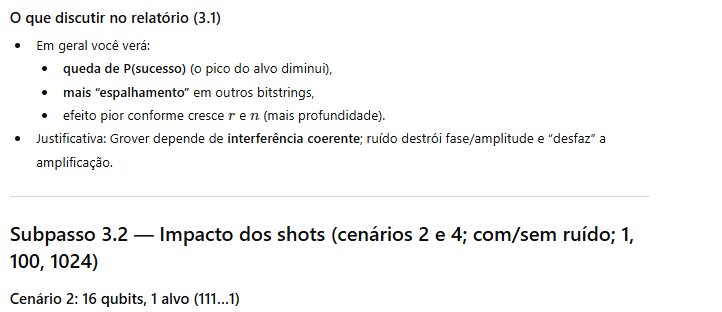

In [ ]:
def experiment_shots(n, targets, shots_list, noise=False, p1=0.003, p2=0.02):
    qc, r = build_grover_circuit(n, targets)
    nm = make_noise_model(p1, p2) if noise else None

    rows = []
    for shots in shots_list:
        counts, t = run_counts(qc, shots=shots, noise_model=nm)
        p = success_probability(counts, n, targets)
        rows.append((shots, t, p, counts))
    return r, rows

shots_list = [1, 100, 1024]

# Cenário 2
n2 = 16
targets2 = [2**16 - 1]

r2_ideal, rows2_ideal = experiment_shots(n2, targets2, shots_list, noise=False)
r2_noisy, rows2_noisy = experiment_shots(n2, targets2, shots_list, noise=True)

print("=== 3.2 Cenário 2 (16 qubits, 1 alvo) ===")
print("r ideal =", r2_ideal)

for shots, t, p, counts in rows2_ideal:
    print(f"Ideal | shots={shots:4d} | tempo={t:.4f}s | P(sucesso)={p:.4f}")
    plot_counts(counts, f"C2 Ideal | shots={shots} | r={r2_ideal}", top=10)

for shots, t, p, counts in rows2_noisy:
    print(f"Ruído | shots={shots:4d} | tempo={t:.4f}s | P(sucesso)={p:.4f}")
    plot_counts(counts, f"C2 Ruído | shots={shots} | r={r2_noisy}", top=10)

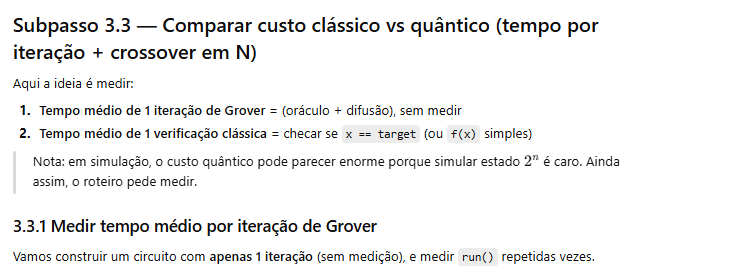

In [ ]:
def build_one_grover_iteration_circuit(n: int, targets: list[int]):
    qc = QuantumCircuit(n)
    qc.h(range(n))                 # preparar |s>
    oracle_phase_mark_targets(qc, targets)
    diffuser_operator(qc)
    return qc

def avg_quantum_iteration_time(n: int, targets: list[int], repeats=5):
    qc = build_one_grover_iteration_circuit(n, targets)
    sim = AerSimulator()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        sim.run(qc, shots=1).result()   # shots=1 só para executar
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return float(np.mean(times)), float(np.std(times))

# exemplo: use n=10 ou n=12 para não explodir simulação
t_mean, t_std = avg_quantum_iteration_time(n=10, targets=[2**10-1], repeats=6)
print("Tempo médio 1 iteração Grover (simulação):", t_mean, "+/-", t_std, "s")


In [ ]:
#3.3.2 Medir tempo médio de 1 verificação clássica

def avg_classical_check_time(repeats=2_000_000):
    target = 12345
    t0 = time.perf_counter()
    hits = 0
    for x in range(repeats):
        if x == target:
            hits += 1
    t1 = time.perf_counter()
    return (t1 - t0) / repeats

t_check = avg_classical_check_time()
print("Tempo médio 1 verificação clássica:", t_check, "s")


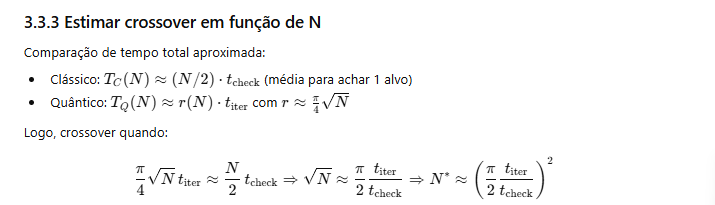

In [ ]:
def estimate_crossover_N(t_iter, t_check):
    return ((math.pi/2) * (t_iter / t_check))**2

# use tempos medidos
N_star = estimate_crossover_N(t_mean, t_check)
print("N* estimado (crossover):", N_star)
print("n* estimado (qubits):", math.log2(N_star))


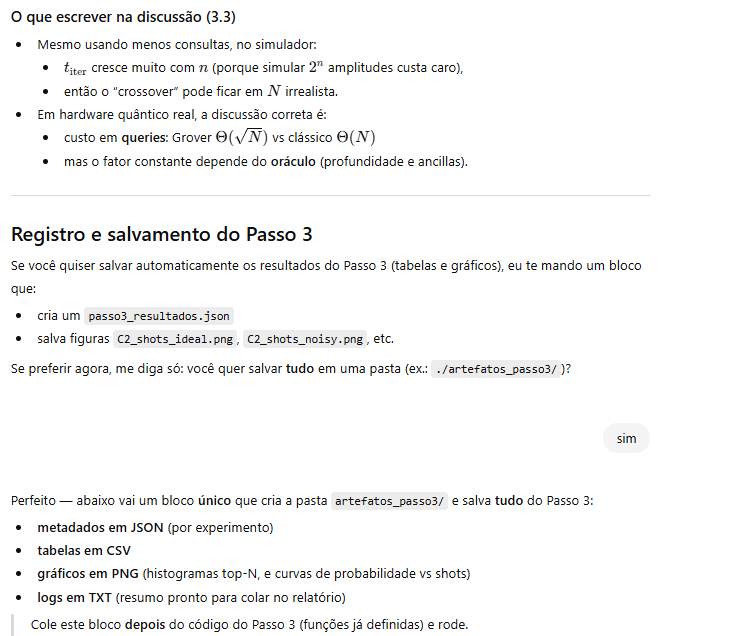

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import time

ARTEF_DIR = "artefatos_passo3"
os.makedirs(ARTEF_DIR, exist_ok=True)

def save_plot_counts_top(counts, filename, title, top=20):
    items = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:top]
    labels = [k for k,_ in items]
    values = [v for _,v in items]
    plt.figure()
    plt.bar(labels, values)
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel("Bitstring")
    plt.ylabel("Counts")
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.close()

def run_and_record(n, targets, shots, noise_flag, noise_params=(0.003, 0.02), tag=""):
    qc, r = build_grover_circuit(n, targets)
    nm = make_noise_model(*noise_params) if noise_flag else None
    counts, t = run_counts(qc, shots=shots, noise_model=nm)
    p = success_probability(counts, n, targets)

    meta = {
        "tag": tag,
        "n": n,
        "targets": targets,
        "k": len(targets),
        "r": r,
        "shots": shots,
        "noise": noise_flag,
        "noise_params": {"p1": noise_params[0], "p2": noise_params[1]} if noise_flag else None,
        "time_s": t,
        "success_probability": p,
    }

    base = f"{tag}_n{n}_k{len(targets)}_shots{shots}_{'noisy' if noise_flag else 'ideal'}"
    # salvar meta
    meta_path = os.path.join(ARTEF_DIR, base + "_meta.json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    # salvar counts
    counts_path = os.path.join(ARTEF_DIR, base + "_counts.json")
    with open(counts_path, "w", encoding="utf-8") as f:
        json.dump(counts, f, indent=2)

    # salvar histograma top
    hist_path = os.path.join(ARTEF_DIR, base + "_hist_top.png")
    save_plot_counts_top(counts, hist_path, f"{tag} | n={n}, k={len(targets)}, r={r}, shots={shots} ({'ruído' if noise_flag else 'ideal'})", top=25)

    return meta, counts, hist_path


# =========================
# 3.1 — Ruído vs Ideal (um circuito)
# =========================
def passo3_1_ruido(tag="P3_1", n=5, targets=[3], shots=1024):
    m1, c1, h1 = run_and_record(n, targets, shots, noise_flag=False, tag=tag)
    m2, c2, h2 = run_and_record(n, targets, shots, noise_flag=True,  tag=tag)
    return [m1, m2]


# =========================
# 3.2 — Shots (cenários 2 e 4) com/sem ruído
# =========================
def passo3_2_shots(tag, n, targets, shots_list=(1,100,1024)):
    metas = []
    for noise_flag in [False, True]:
        for shots in shots_list:
            m, _, _ = run_and_record(n, targets, shots, noise_flag=noise_flag, tag=tag)
            metas.append(m)
    return metas


def save_shots_curve(metas, filename, title):
    # metas: lista de dicts
    df = pd.DataFrame(metas)
    plt.figure()
    for noise_flag, grp in df.groupby("noise"):
        grp = grp.sort_values("shots")
        plt.plot(grp["shots"], grp["success_probability"], marker="o", label=("Com ruído" if noise_flag else "Ideal"))
    plt.xscale("log")
    plt.xlabel("Shots (escala log)")
    plt.ylabel("Probabilidade de sucesso")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.close()


# =========================
# 3.3 — Custo: iteração Grover vs verificação clássica + crossover
# =========================
def avg_quantum_iteration_time(n: int, targets: list[int], repeats=6):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    oracle_phase_mark_targets(qc, targets)
    diffuser_operator(qc)

    sim = AerSimulator()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        sim.run(qc, shots=1).result()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return float(np.mean(times)), float(np.std(times))

def avg_classical_check_time(repeats=2_000_000):
    target = 12345
    t0 = time.perf_counter()
    hits = 0
    for x in range(repeats):
        if x == target:
            hits += 1
    t1 = time.perf_counter()
    return (t1 - t0) / repeats

def estimate_crossover_N(t_iter, t_check):
    return ((math.pi/2) * (t_iter / t_check))**2

def passo3_3_custo(tag="P3_3", n_for_iter=10):
    # Medir tempo médio por iteração de Grover (simulação)
    t_iter_mean, t_iter_std = avg_quantum_iteration_time(n_for_iter, [2**n_for_iter - 1], repeats=6)

    # Medir tempo médio verificação clássica
    t_check = avg_classical_check_time(repeats=2_000_000)

    N_star = estimate_crossover_N(t_iter_mean, t_check)
    n_star = math.log2(N_star) if N_star > 0 else None

    meta = {
        "tag": tag,
        "n_for_iter": n_for_iter,
        "t_iter_mean_s": t_iter_mean,
        "t_iter_std_s": t_iter_std,
        "t_check_mean_s": t_check,
        "N_crossover_est": N_star,
        "n_crossover_est": n_star
    }

    path = os.path.join(ARTEF_DIR, f"{tag}_custo_crossover.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    # log txt
    log_path = os.path.join(ARTEF_DIR, f"{tag}_custo_crossover.txt")
    with open(log_path, "w", encoding="utf-8") as f:
        f.write("=== Passo 3.3: custo clássico vs quântico (simulador) ===\n")
        f.write(f"Tempo médio 1 iteração Grover (n={n_for_iter}): {t_iter_mean:.6e} +/- {t_iter_std:.6e} s\n")
        f.write(f"Tempo médio 1 verificação clássica: {t_check:.6e} s\n")
        f.write(f"N* estimado (crossover): {N_star:.3e}\n")
        f.write(f"n* estimado (log2 N*): {n_star:.2f}\n")
        f.write("\nObservação: tempos são do simulador clássico; em hardware real a comparação relevante é a complexidade em consultas.\n")

    return meta


# =========================
# EXECUTAR PASSO 3 COMPLETO
# =========================
all_metas = []

# 3.1
metas_31 = passo3_1_ruido(tag="P3_1_Ruido", n=5, targets=[3], shots=1024)
all_metas += metas_31

# 3.2 Cenário 2 (16 qubits, 1 alvo) — pode ser pesado; ajuste shots se necessário
metas_32_c2 = passo3_2_shots(tag="P3_2_C2", n=16, targets=[2**16 - 1], shots_list=(1,100,1024))
all_metas += metas_32_c2
save_shots_curve(metas_32_c2,
                 os.path.join(ARTEF_DIR, "P3_2_C2_prob_vs_shots.png"),
                 "Cenário 2 (n=16, k=1): Probabilidade de sucesso vs Shots")

# 3.2 Cenário 4 (5 qubits, múltiplos alvos)
metas_32_c4 = passo3_2_shots(tag="P3_2_C4", n=5, targets=[3,7,11], shots_list=(1,100,1024))
all_metas += metas_32_c4
save_shots_curve(metas_32_c4,
                 os.path.join(ARTEF_DIR, "P3_2_C4_prob_vs_shots.png"),
                 "Cenário 4 (n=5, k=3): Probabilidade de sucesso vs Shots")

# 3.3
meta_33 = passo3_3_custo(tag="P3_3", n_for_iter=10)

# salvar tabela geral
df = pd.DataFrame(all_metas)
csv_path = os.path.join(ARTEF_DIR, "passo3_resumo.csv")
df.to_csv(csv_path, index=False)

# salvar um log-resumo
log_path = os.path.join(ARTEF_DIR, "passo3_resumo.txt")
with open(log_path, "w", encoding="utf-8") as f:
    f.write("=== PASSO 3 — Resumo dos experimentos ===\n\n")
    f.write(df.to_string(index=False))
    f.write("\n\n=== PASSO 3.3 — Crossover (estimativa) ===\n")
    f.write(json.dumps(meta_33, indent=2))
    f.write("\n")

print(f"✅ Tudo salvo em: {ARTEF_DIR}/")
print(f"- Tabela: {csv_path}")
print(f"- Curvas: {ARTEF_DIR}/P3_2_C2_prob_vs_shots.png e {ARTEF_DIR}/P3_2_C4_prob_vs_shots.png")
print(f"- Resumo TXT: {log_path}")
print(f"- Crossover: {ARTEF_DIR}/P3_3_custo_crossover.json")


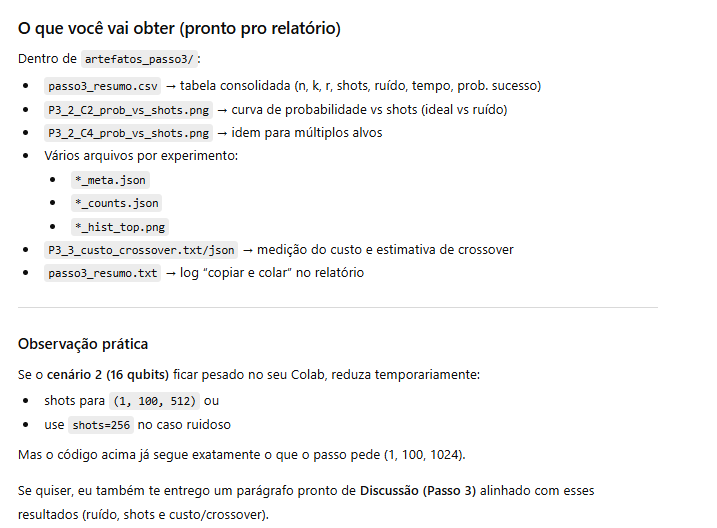